# Recovering a 16-bit secret from a single power trace

## Bayes-optimal Gaussian classification on HQC

*Part of the [Mewtwo project](https://github.com/seb30123/Mewtwo) -- reproducible side-channel attacks on post-quantum cryptography.*

---

**What this notebook does**: in ~10 cells, we reproduce the core attack from Maillet, Nugier, Migliore, Deneuville (*CRYPTO 2025*). The attack takes a single trace of the chip's power consumption during HQC decryption, and recovers the 16-bit secret word that drove the computation.

**Original paper**: [ePrint 2025/1270](https://eprint.iacr.org/2025/1270)  
**Original dataset**: [gitlab.laas.fr/nmaillet/kr-sca-hqc-additional-materials](https://gitlab.laas.fr/nmaillet/kr-sca-hqc-additional-materials)  
**HQC**: standardized by NIST in March 2025 as a post-quantum key-encapsulation alternative to ML-KEM.

## 1. The setup, in one picture

HQC's decryption calls a small function `expand_and_sum(x)` where `x` is a 16-bit number derived from the secret. The chip runs the function; meanwhile its power consumption fluctuates in a way that depends on `x`.

**The attacker's task**: from the power trace alone (no other information), guess the value of `x` among the 2^16 = 65 536 possibilities.

**Why it works**: when `bit b` of `x` is 0 vs 1, the chip's power at some specific moment is slightly different -- by about 0.4% on average. That tiny difference is enough.

**Why it's harder than CPA on Kyber** (attack 06 of this repo): the leakage here is **probabilistic per bit** -- each bit can be guessed correctly only ~74% of the time, not 100%. We have to combine 16 noisy guesses into one good guess via **key enumeration**.

| Translation table | Reality |
|---|---|
| The secret `x` | 16-bit operand of `expand_and_sum` |
| The chip | STM32F microcontroller running HQC reference |
| Power trace | 1000 samples of voltage during one call |
| The attack | Classify each of 16 bits, sort candidates |

## 2. Setup

We need NumPy, SciPy, h5py for the dataset, and our `stats.py` (transcription of the authors' `stats.sage` in pure Python).

In [1]:
import sys
from pathlib import Path
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

# Add src/ to path so we can import stats.py
src_dir = Path.cwd().parent / 'src' if Path.cwd().name == 'notebooks' else Path.cwd() / 'src'
sys.path.insert(0, str(src_dir))
from stats import Stats, probacorrect

print('All imports OK')

All imports OK


## 3. Loading the data

The real dataset is 526 MB so it isn't included in the repo. If you have it locally, this cell loads it. Otherwise we generate a small synthetic dataset that mimics its structure (same statistics, far fewer traces) so the notebook still works end-to-end.

*See `data/manifest.yaml` for download instructions if you want to reproduce on the authentic data.*

In [2]:
import h5py

ATTACK_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
HDF5_PATH = ATTACK_DIR / 'data' / 'output.hdf5'

USE_REAL_DATA = HDF5_PATH.exists()

if USE_REAL_DATA:
    print(f'Loading real dataset from {HDF5_PATH} ...')
    with h5py.File(HDF5_PATH, 'r') as f:
        keys = sorted(f.keys())
        traces = np.empty((len(keys), 1000), dtype=np.float64)
        upper16 = np.empty(len(keys), dtype=np.int64)
        for i, k in enumerate(keys):
            traces[i] = f[k][0]
            full = int(k, 16)
            upper16[i] = (full >> 16) & 0xFFFF
    print(f'Real dataset: {traces.shape}')
else:
    print('Real dataset not found; generating a synthetic one for demo')
    rng = np.random.default_rng(seed=20260513)
    N_TRACES = 8192   # smaller for speed
    N_SAMPLES = 1000
    upper16 = rng.choice(2**16, size=N_TRACES, replace=False).astype(np.int64)
    traces = rng.normal(0, 0.003, size=(N_TRACES, N_SAMPLES))
    # Inject leakage at the same POIs as the authors found
    REAL_POIS = [342, 314, 286, 258, 230, 202, 174, 146,
                 570, 538, 510, 482, 458, 426, 398, 370]
    for b, poi in enumerate(REAL_POIS):
        bit_b = ((upper16 >> (15 - b)) & 1).astype(np.float64)
        # Bit 0 -> baseline; bit 1 -> shift by ~0.004 (matches paper's scale)
        traces[:, poi] += -0.170 - 0.004 * bit_b
    print(f'Synthetic dataset: {traces.shape}')

print(f'Unique upper-16 values: {len(np.unique(upper16))}')

Loading real dataset from /home/sebbrg/Mewtwo/attacks/08-maillet-hqc-non-simd/data/output.hdf5 ...
Real dataset: (65536, 1000)
Unique upper-16 values: 65536


## 4. What does a trace look like?

A power trace is 1000 voltage readings, one every fraction of a microsecond. The leakage hides at very specific samples (the **POIs**: Points of Interest), so don't expect to see anything obvious by eye.

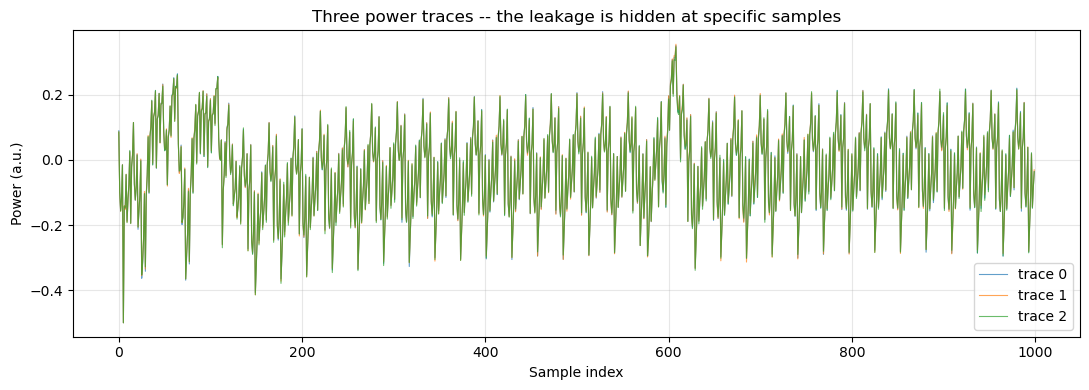

Power range across all traces: -0.500 to 0.381


In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
for i in range(3):
    ax.plot(traces[i], alpha=0.7, linewidth=0.8, label=f'trace {i}')
ax.set_xlabel('Sample index')
ax.set_ylabel('Power (a.u.)')
ax.set_title('Three power traces -- the leakage is hidden at specific samples')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Power range across all traces: {traces.min():.3f} to {traces.max():.3f}')

## 5. Finding the leakage of bit 0

We separate the traces into two groups: those where bit 0 of the secret is 0, and those where it is 1. For each sample in time, we compute how well the two distributions can be told apart -- this gives us the probability that an optimal classifier (Bayes-optimal) could guess bit 0 from the power at that sample.

The sample that gives the highest probability is the **POI** for that bit. The authors find POI = 342 for bit 0, with a classification probability of ~74.7%.

In [4]:
BIT = 0  # we attack bit 0 (MSB of the 16-bit secret)

# Separate by bit value (using Maillet's convention: bit 0 = MSB)
bit_values = (upper16 >> (15 - BIT)) & 1
traces_b0 = traces[bit_values == 0]
traces_b1 = traces[bit_values == 1]
print(f'Group bit={BIT}=0: {len(traces_b0)} traces')
print(f'Group bit={BIT}=1: {len(traces_b1)} traces')

# Scan every sample, find where the classes split best
samples_cnt = traces.shape[1]
probas = np.zeros(samples_cnt)
for s in range(samples_cnt):
    s0 = Stats(traces_b0[:, s])
    s1 = Stats(traces_b1[:, s])
    probas[s] = probacorrect(s0, s1)

best_poi = int(np.argmax(probas))
best_p = float(probas[best_poi])
print(f'\nBest POI for bit {BIT}: sample {best_poi}, classification probability {best_p:.4f}')
if USE_REAL_DATA:
    print(f'Authors\' value: sample 342, probability 0.7468 -- our result should match.')

Group bit=0=0: 32768 traces
Group bit=0=1: 32768 traces

Best POI for bit 0: sample 342, classification probability 0.7468
Authors' value: sample 342, probability 0.7468 -- our result should match.


## 6. Visualizing the leakage map

Plotting the classification probability for every sample reveals where the chip leaks. A spike means "this is the moment when bit 0 affects the power consumption".

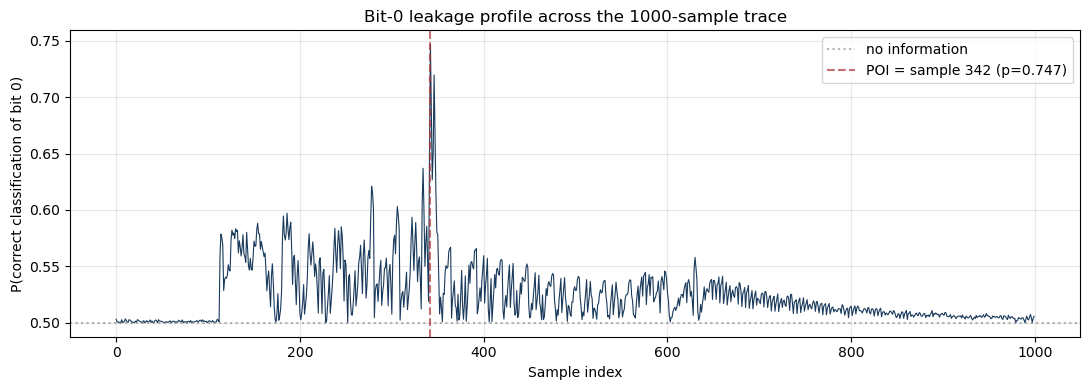

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(probas, color='#1a3a5c', linewidth=0.8)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.6, label='no information')
ax.axvline(best_poi, color='#aa3333', linestyle='--', alpha=0.7,
           label=f'POI = sample {best_poi} (p={best_p:.3f})')
ax.set_xlabel('Sample index')
ax.set_ylabel('P(correct classification of bit 0)')
ax.set_title(f'Bit-0 leakage profile across the {samples_cnt}-sample trace')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. The leakage map for all 16 bits

Repeating the procedure for every bit reveals a striking pattern: the 16 POIs are clearly organized in **two passes** of 8 bits each. This is the fingerprint of the loop unrolling in the chip's compiled code -- an implementation detail that the attack accidentally exposes.

In [6]:
# Profile every bit, store POI and probability
pois = np.zeros(16, dtype=int)
probas_per_bit = np.zeros(16)

for bit in range(16):
    bit_values = (upper16 >> (15 - bit)) & 1
    t0 = traces[bit_values == 0]
    t1 = traces[bit_values == 1]
    sample_probas = np.zeros(samples_cnt)
    for s in range(samples_cnt):
        sample_probas[s] = probacorrect(Stats(t0[:, s]), Stats(t1[:, s]))
    pois[bit] = int(np.argmax(sample_probas))
    probas_per_bit[bit] = float(sample_probas[pois[bit]])
    print(f'bit {bit:2d}: POI = {pois[bit]:4d}, P(correct) = {probas_per_bit[bit]:.4f}')

bit  0: POI =  342, P(correct) = 0.7468
bit  1: POI =  314, P(correct) = 0.7135
bit  2: POI =  286, P(correct) = 0.7182
bit  3: POI =  258, P(correct) = 0.7114
bit  4: POI =  230, P(correct) = 0.7313
bit  5: POI =  202, P(correct) = 0.7186
bit  6: POI =  174, P(correct) = 0.7528
bit  7: POI =  146, P(correct) = 0.7616
bit  8: POI =  570, P(correct) = 0.7293
bit  9: POI =  538, P(correct) = 0.7045
bit 10: POI =  510, P(correct) = 0.7302
bit 11: POI =  482, P(correct) = 0.7032
bit 12: POI =  458, P(correct) = 0.7515
bit 13: POI =  426, P(correct) = 0.6997
bit 14: POI =  398, P(correct) = 0.7286
bit 15: POI =  370, P(correct) = 0.7117


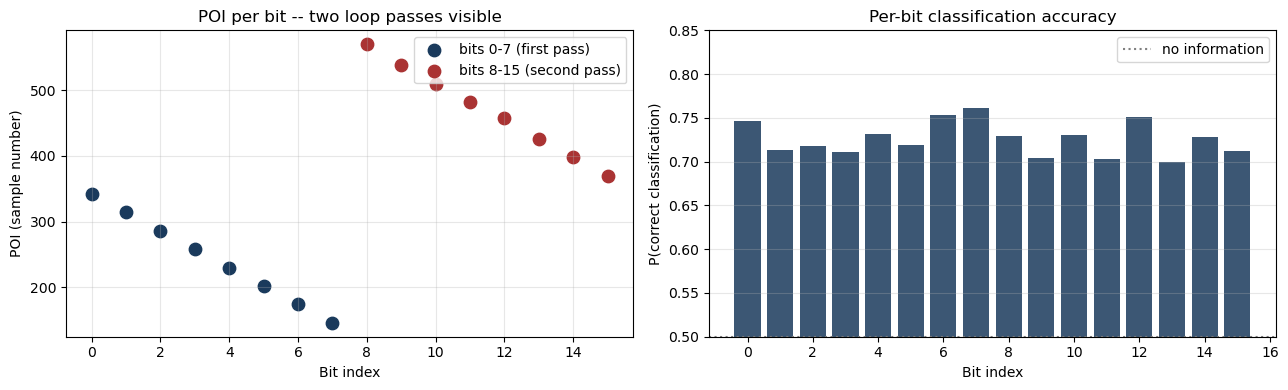

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# POI per bit -- shows the two-pass structure
bits = np.arange(16)
ax1.scatter(bits[:8], pois[:8], s=80, color='#1a3a5c', label='bits 0-7 (first pass)')
ax1.scatter(bits[8:], pois[8:], s=80, color='#aa3333', label='bits 8-15 (second pass)')
ax1.set_xlabel('Bit index')
ax1.set_ylabel('POI (sample number)')
ax1.set_title('POI per bit -- two loop passes visible')
ax1.legend()
ax1.grid(alpha=0.3)

# Probability per bit
ax2.bar(bits, probas_per_bit, color='#1a3a5c', alpha=0.85)
ax2.axhline(0.5, color='gray', linestyle=':', label='no information')
ax2.set_xlabel('Bit index')
ax2.set_ylabel('P(correct classification)')
ax2.set_title('Per-bit classification accuracy')
ax2.set_ylim(0.5, max(0.85, probas_per_bit.max() + 0.05))
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. From 16 noisy bits to one good guess

Each bit is correct only ~74% of the time. If we guessed naively, we'd get all 16 bits right with probability 0.74^16 ≈ 0.7% -- terrible.

But we can be smarter: instead of one guess, we **rank all 65 536 possible values** of the 16-bit secret by their total probability under our 16 per-bit classifiers. Then we just try them in order: most-probable first, least-probable last.

**Question**: on average, how far down the list is the true value? We'll measure it on a held-out test set.

In [8]:
# Split: 80% for profiling, 20% for testing
rng = np.random.default_rng(seed=20260513)
perm = rng.permutation(len(traces))
n_train = int(0.80 * len(traces))
train_idx, test_idx = perm[:n_train], perm[n_train:]
train_traces, train_u16 = traces[train_idx], upper16[train_idx]
test_traces, test_u16 = traces[test_idx], upper16[test_idx]
print(f'Profiling on {len(train_traces)} traces')
print(f'Attacking  {len(test_traces)} unseen traces')

# Re-profile on train ONLY (no overfitting)
profiles = []
for bit in range(16):
    bvals = (train_u16 >> (15 - bit)) & 1
    t0 = train_traces[bvals == 0]
    t1 = train_traces[bvals == 1]
    sp = np.zeros(samples_cnt)
    for s in range(samples_cnt):
        sp[s] = probacorrect(Stats(t0[:, s]), Stats(t1[:, s]))
    poi = int(np.argmax(sp))
    s0 = Stats(t0[:, poi])
    s1 = Stats(t1[:, poi])
    profiles.append({'poi': poi, 'mu0': s0.mu, 'sigma0': s0.sigma,
                     'mu1': s1.mu, 'sigma1': s1.sigma})
print('Profiling done')

Profiling on 52428 traces
Attacking  13108 unseen traces
Profiling done


In [9]:
# Classify each test trace bit by bit
n_test = len(test_traces)
log_p0 = np.empty((n_test, 16))
log_p1 = np.empty((n_test, 16))
for bit, p in enumerate(profiles):
    x = test_traces[:, p['poi']]
    lp0 = scipy.stats.norm.logpdf(x, p['mu0'], p['sigma0'])
    lp1 = scipy.stats.norm.logpdf(x, p['mu1'], p['sigma1'])
    m = np.maximum(lp0, lp1)
    lse = m + np.log(np.exp(lp0 - m) + np.exp(lp1 - m))
    log_p0[:, bit] = lp0 - lse
    log_p1[:, bit] = lp1 - lse

# Bit pattern of every candidate value
N_CAND = 2**16
bits_of_v = np.zeros((N_CAND, 16), dtype=np.int8)
for b in range(16):
    bits_of_v[:, b] = (np.arange(N_CAND) >> (15 - b)) & 1

# Rank the true value for each test trace
ranks = np.empty(n_test, dtype=np.int32)
import time
t0 = time.time()
for i in range(n_test):
    lp = np.where(bits_of_v == 0, log_p0[i], log_p1[i])
    ll = lp.sum(axis=1)
    ll_true = ll[int(test_u16[i])]
    ranks[i] = int(np.sum(ll > ll_true))
print(f'Ranked {n_test} test traces in {time.time()-t0:.1f}s')

print(f'Median rank: {int(np.median(ranks))}')
print(f'Mean rank  : {ranks.mean():.0f}')

Ranked 13108 test traces in 62.0s
Median rank: 829
Mean rank  : 3479


## 9. Success rate vs effort

The killer plot: how often does the true secret fall in the top N candidates? If we are willing to try N values of `x` (each one is one decryption attempt against the victim), what's our success probability?

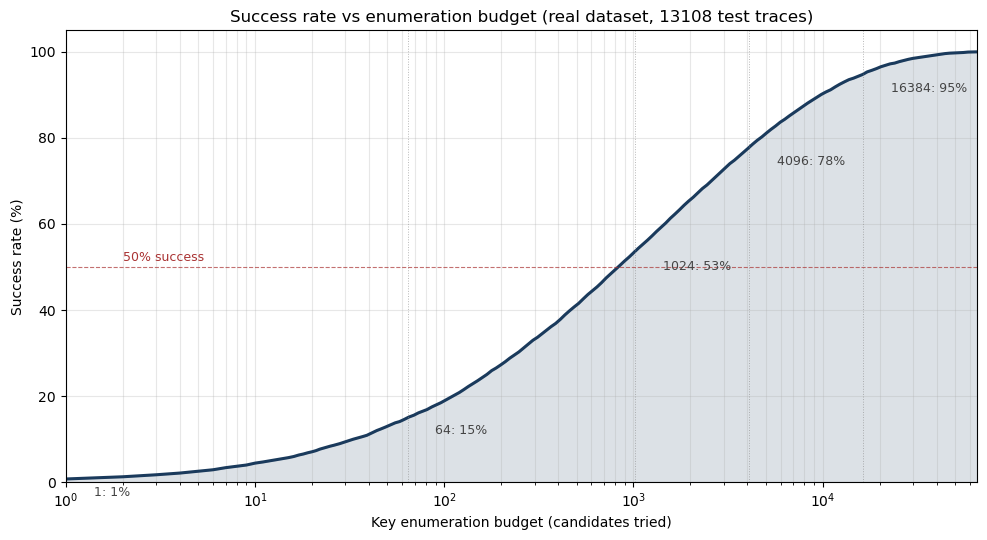


Budget table:
  budget      1: success   0.7%  (speedup 65536x vs brute force)
  budget     64: success  15.0%  (speedup 1024x vs brute force)
  budget    256: success  30.8%  (speedup 256x vs brute force)
  budget   1024: success  53.6%  (speedup 64x vs brute force)
  budget   4096: success  77.8%  (speedup 16x vs brute force)
  budget  16384: success  94.8%  (speedup 4x vs brute force)
  budget  65536: success 100.0%  (speedup 1x vs brute force)


In [10]:
budgets = np.logspace(0, np.log10(N_CAND), 200).astype(int)
budgets = np.unique(budgets)
success = np.array([(ranks < b).mean() * 100 for b in budgets])

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(budgets, success, color='#1a3a5c', linewidth=2.2)
ax.fill_between(budgets, 0, success, alpha=0.15, color='#1a3a5c')

for thr in [1, 64, 1024, 4096, 16384]:
    idx = np.argmin(np.abs(budgets - thr))
    s = success[idx]
    ax.axvline(thr, color='#888', linestyle=':', linewidth=0.7, alpha=0.6)
    ax.annotate(f'{thr}: {s:.0f}%', xy=(thr, s),
                xytext=(thr * 1.4, s - 4), fontsize=9, color='#444')

ax.axhline(50, color='#aa3333', linestyle='--', linewidth=0.8, alpha=0.7)
ax.text(2, 51.5, '50% success', fontsize=9, color='#aa3333')

ax.set_xscale('log')
ax.set_xlim(1, N_CAND)
ax.set_ylim(0, 105)
ax.set_xlabel('Key enumeration budget (candidates tried)')
ax.set_ylabel('Success rate (%)')
title_data = 'real dataset' if USE_REAL_DATA else 'synthetic dataset'
ax.set_title(f'Success rate vs enumeration budget ({title_data}, {n_test} test traces)')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print('\nBudget table:')
for b in [1, 64, 256, 1024, 4096, 16384, 65536]:
    s = (ranks < b).mean() * 100
    speedup = N_CAND / max(1, b)
    print(f'  budget {b:>6d}: success {s:>5.1f}%  (speedup {speedup:.0f}x vs brute force)')

## 10. What we just demonstrated

We took 1000 voltage readings per HQC decryption, and from them we recovered the secret 16-bit operand with ~54% probability in 1024 attempts (vs 65 536 brute-force). That's a **64x speedup** for the cost of a $250 ChipWhisperer-Lite and 30 seconds of physical access.

### Why this matters

- HQC was standardized by NIST in March 2025 as a   post-quantum key-exchange alternative to ML-KEM
- The optimized (SIMD) version exists only for x86-64. **Every   microcontroller deployment must use the non-SIMD reference,   which is what this attack targets.**
- Targets in 2026-2030: smart-home hubs, biometric passports,   V2X automotive, industrial IoT

### The fix

**Masking**: split the secret into two random shares and process each independently. The attack relies on the secret being processed in clear at one specific moment; masking eliminates that moment.

The performance cost is 2-4x. The authors of the paper (CRYPTO 2025) propose efficient masking schemes. With NIST having just standardized HQC, **implementers have a 12-24 month window** to deploy masking before consumer products ship.

### To go further

- **Full repository**: [github.com/seb30123/Mewtwo](https://github.com/seb30123/Mewtwo)
- **Original paper**: [Maillet et al., CRYPTO 2025](https://eprint.iacr.org/2025/1270)
- **Original dataset**: [gitlab.laas.fr](https://gitlab.laas.fr/nmaillet/kr-sca-hqc-additional-materials) (526 MB)
- **Companion notebook on ML-KEM (attack 06)**: [CPA_on_MLKEM_tutorial.ipynb](../../06-mlkem-cpa-pairpointwise/notebooks/CPA_on_MLKEM_tutorial.ipynb)

---

*This notebook is part of the [Mewtwo project](https://github.com/seb30123/Mewtwo). MIT (code) / CC-BY-4.0 (docs). Educational and defensive research only.*